In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Librerías importadas correctamente ✅")

Librerías importadas correctamente ✅


In [7]:
# Cargo el dataset California Housing desde archivo local
df = pd.read_csv('housing.csv')

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
# Reviso valores nulos y tipos de datos
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Tipos de datos:")
print(df.dtypes)

Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Tipos de datos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [9]:
# Elimino las filas con nulos en total_bedrooms
df = df.dropna(subset=['total_bedrooms'])

# Convierto ocean_proximity a columnas numéricas
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("Filas después de limpiar:", len(df))
print("Columnas:", df.columns.tolist())

Filas después de limpiar: 20433
Columnas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
# X son todas las columnas menos el precio
# y es el precio que queremos predecir
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (20433, 12)
Forma de y: (20433,)


In [12]:
# Divido 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16346, 12)
Test: (4087, 12)


In [ ]:
# Escalo las features para que todas estén en la misma escala
scaler = StandardScaler()

# fit_transform solo en train — aprende la escala del train
X_train = scaler.fit_transform(X_train)

# transform en test — aplica la misma escala, no aprende de nuevo
X_test = scaler.transform(X_test)

print("Escalado listo")

Escalado listo ✅


In [ ]:
# Creo el modelo y lo entreno con los datos de train
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado ✅


In [15]:
# El modelo predice los precios del test
y_pred = modelo.predict(X_test)

# Calculo el RMSE y R2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.0f}")
print(f"R2: {r2:.4f}")

RMSE: $69,298
R2: 0.6488


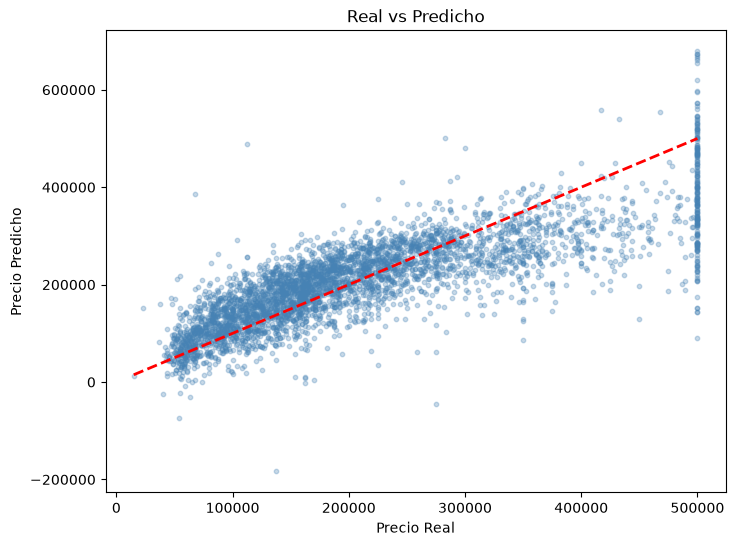

In [16]:
# Grafico los precios reales vs los predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Real vs Predicho')
plt.show()

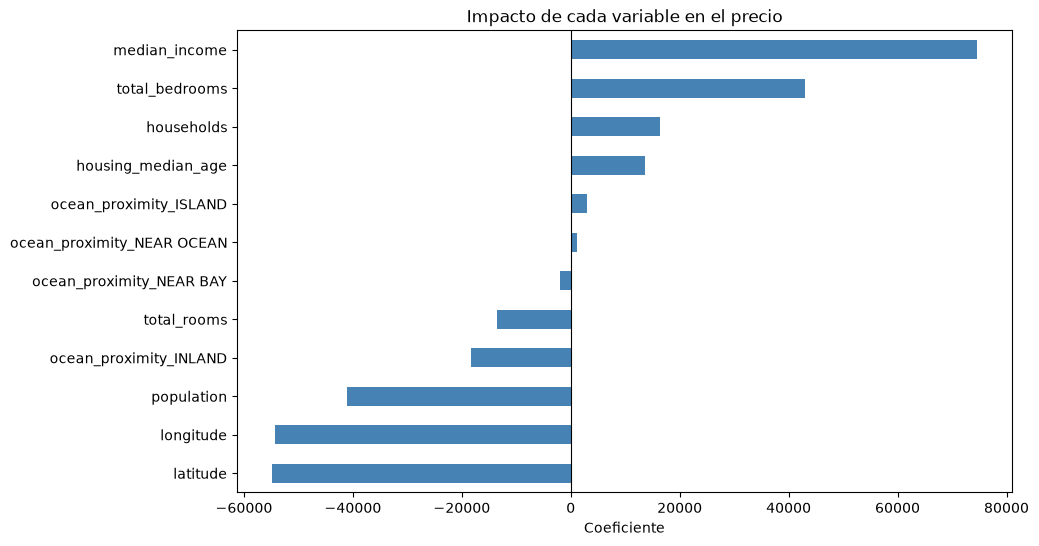

In [17]:
# Grafico los coeficientes del modelo
coeficientes = pd.Series(modelo.coef_, index=X.columns)
coeficientes = coeficientes.sort_values()

plt.figure(figsize=(10, 6))
coeficientes.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto de cada variable en el precio')
plt.xlabel('Coeficiente')
plt.show()